In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
import joblib


In [4]:
pd.set_option('display.max_columns', None)
%matplotlib inline

In [5]:
df= pd.read_csv(r"C:\Users\LENOVO\Desktop\MLproject\data\processed\df_clean_start.csv")
print("shape:",df.shape)
df.head()

shape: (4372, 52)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueProducts,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,RegistrationDate,NewsletterSubscribed,LastLoginIP,SupportTicketsCount,SatisfactionScore,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,12,71,374,3,9,12,0.000000,0.221865,24,25,0.685714,1,15,0,15,0.048077,312,35,8.914286,NaN,17/07/10,Yes,59.252.219.201,1.0,4.0,Fidèles,Inconnu,VIP,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,32,342,374,2,13,10,0.168367,1.717949,106,106,5.888889,1,24,0,24,0.122449,196,18,10.888889,NaN,2010-10-04,Yes,77.255.247.14,3.0,4.0,Champions,Inconnu,VIP,Régulier,Automne,Midi,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,360,370,374,4,12,11,0.055777,1.456000,115,117,6.388889,1,4,0,4,0.015936,251,18,13.944444,46.0,12/09/2009,Yes,51.139.78.80,2.0,5.0,Champions,45-54,VIP,Hyperactif,Automne,Midi,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,80,278,374,0,9,9,0.000000,10.259259,24,24,4.800000,1,0,0,0,0.000000,28,5,5.600000,32.0,28/01/10,Yes,10.212.80.124,2.0,2.0,Potentiels,25-34,High,Nouveau,Automne,Matin,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,32,43,374,2,9,12,0.000000,8.200000,1,1,0.166667,1,3,0,3,0.500000,6,6,1.000000,NaN,2009-12-10,Yes,186.34.121.80,2.0,1.0,Potentiels,Inconnu,High,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [8]:
# Colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numériques:", numeric_cols)

Numériques: ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'Churn']


In [7]:
# Colonnes catégorielles (object)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Catégorielles:", categorical_cols)

Catégorielles: ['RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country']


In [9]:
target= 'Churn'

In [11]:
X= df.drop(columns=[target])
y = df[target]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Taille train: {X_train.shape}")
print(f"Taille test: {X_test.shape}")
print(f"Distribution cible dans train:\n{y_train.value_counts(normalize=True)}")

Taille train: (3497, 51)
Taille test: (875, 51)
Distribution cible dans train:
Churn
0    0.667429
1    0.332571
Name: proportion, dtype: float64


In [13]:
missing_train = X_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print("Valeurs manquantes dans train:\n", missing_train)


Valeurs manquantes dans train:
 Age                        1061
AvgDaysBetweenPurchases      66
dtype: int64


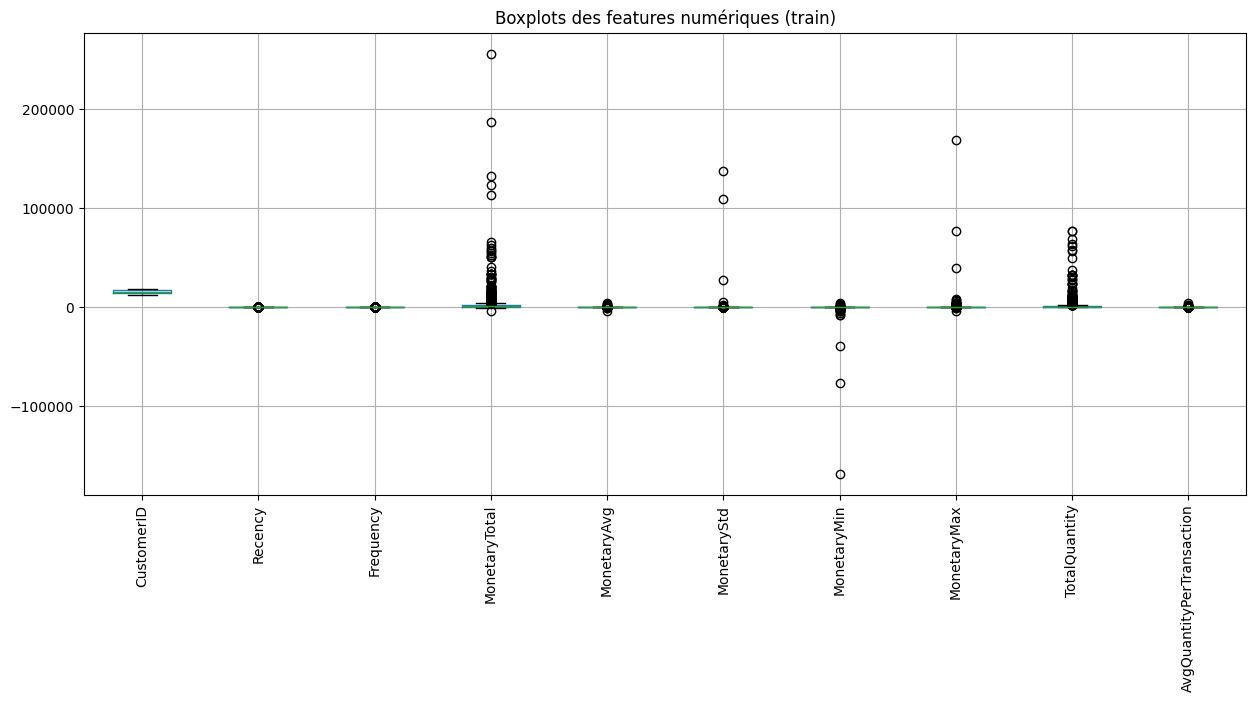

In [16]:
# Sélectionner quelques colonnes numériques pour visualiser les outliers
num_cols_sample = numeric_cols[:10]  # les 10 premières
X_train[num_cols_sample].boxplot(figsize=(15, 6), rot=90)
plt.title("Boxplots des features numériques (train)")
plt.show()

In [17]:
# Détection des colonnes constantes dans train
constant_cols = [col for col in X_train.columns if X_train[col].nunique() == 1]
print("Colonnes constantes à supprimer:", constant_cols)

Colonnes constantes à supprimer: ['NewsletterSubscribed']


In [18]:
# Supprimer ces colonnes de X_train et X_test
X_train = X_train.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

# Mettre à jour les listes de colonnes
numeric_cols = [col for col in numeric_cols if col not in constant_cols]
categorical_cols = [col for col in categorical_cols if col not in constant_cols]

In [20]:
# ### 6.2 Traitement des valeurs manquantes
# - Pour les numériques : imputation par la médiane (robuste aux outliers)
# - Pour les catégorielles : imputation par le mode (valeur la plus fréquente)
# Imputation numérique
num_imputer = SimpleImputer(strategy='median')
# Imputation catégorielle
cat_imputer = SimpleImputer(strategy='most_frequent')

In [21]:
def cap_outliers(X, lower_percentile=0.01, upper_percentile=0.99):
    """Applique le capping sur un DataFrame X (doit être numérique)."""
    X_capped = X.copy()
    for col in X_capped.columns:
        if pd.api.types.is_numeric_dtype(X_capped[col]):
            lower = X_capped[col].quantile(lower_percentile)
            upper = X_capped[col].quantile(upper_percentile)
            X_capped[col] = X_capped[col].clip(lower, upper)
    return X_capped

In [22]:
# Vérifions les colonnes disponibles pour le feature engineering
print("Colonnes disponibles:", X_train.columns.tolist())

# On va créer un dictionnaire pour stocker les nouvelles features
# On les ajoutera après l'imputation et avant la normalisation.

# Exemple : si 'MonetaryTotal' et 'Recency' existent
if 'MonetaryTotal' in X_train.columns and 'Recency' in X_train.columns:
    X_train['MonetaryPerDay'] = X_train['MonetaryTotal'] / (X_train['Recency'] + 1)
    X_test['MonetaryPerDay'] = X_test['MonetaryTotal'] / (X_test['Recency'] + 1)

if 'MonetaryTotal' in X_train.columns and 'Frequency' in X_train.columns:
    X_train['AvgBasketValue'] = X_train['MonetaryTotal'] / X_train['Frequency']
    X_test['AvgBasketValue'] = X_test['MonetaryTotal'] / X_test['Frequency']

if 'Recency' in X_train.columns and 'CustomerTenure' in X_train.columns:
    X_train['TenureRatio'] = X_train['Recency'] / (X_train['CustomerTenure'] + 1)
    X_test['TenureRatio'] = X_test['Recency'] / (X_test['CustomerTenure'] + 1)


Colonnes disponibles: ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'RegistrationDate', 'LastLoginIP', 'SupportTicketsCount', 'SatisfactionScore', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country']


In [23]:

# Si 'RegistrationDate' existe (colonne texte)
if 'RegistrationDate' in X_train.columns:
    # Convertir en datetime
    X_train['RegistrationDate'] = pd.to_datetime(X_train['RegistrationDate'], errors='coerce')
    X_test['RegistrationDate'] = pd.to_datetime(X_test['RegistrationDate'], errors='coerce')
    
    # Extraire des features
    X_train['RegYear'] = X_train['RegistrationDate'].dt.year
    X_train['RegMonth'] = X_train['RegistrationDate'].dt.month
    X_test['RegYear'] = X_test['RegistrationDate'].dt.year
    X_test['RegMonth'] = X_test['RegistrationDate'].dt.month
    
    # Supprimer la colonne d'origine
    X_train = X_train.drop(columns=['RegistrationDate'])
    X_test = X_test.drop(columns=['RegistrationDate'])
    
    # Ajouter ces nouvelles colonnes aux listes numériques
    numeric_cols.extend(['RegYear', 'RegMonth'])

# Mettre à jour la liste des colonnes numériques après ajout
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("Nouvelles colonnes numériques:", numeric_cols)
print("Nouvelles colonnes catégorielles:", categorical_cols)

Nouvelles colonnes numériques: ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'MonetaryPerDay', 'AvgBasketValue', 'RegYear', 'RegMonth']
Nouvelles colonnes catégorielles: ['LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'Accou

In [34]:
ordinal_cols = ['AgeCategory', 'SpendingCategory', 'LoyaltyLevel', 'ChurnRiskCategory', 'BasketSizeCategory']  # liste indicative

In [35]:
# Vérifier quelles colonnes existent réellement
ordinal_cols = [col for col in ordinal_cols if col in categorical_cols]
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

print("Ordinales:", ordinal_cols)
print("Nominales:", nominal_cols)

Ordinales: ['AgeCategory', 'SpendingCategory', 'LoyaltyLevel', 'ChurnRiskCategory', 'BasketSizeCategory']
Nominales: ['LastLoginIP', 'RFMSegment', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'WeekendPreference', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country']


In [36]:
#capping sur X_train et X_test (en utilisant les bornes de train)
caps = {}
for col in numeric_cols:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    caps[col] = (lower, upper)

# Appliquer le capping
for col in numeric_cols:
    lower, upper = caps[col]
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)


In [37]:
# 1. Pipeline pour les numériques : imputation médiane + capping + standardisation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [38]:

# 2. Pipeline pour les ordinales : imputation par le mode + encodage ordinal
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [39]:
# 3. Pipeline pour les nominales : imputation par le mode + one-hot encoding (drop='first' pour éviter colinéarité)
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])


In [40]:
# Combiner le tout dans un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('ord', ordinal_transformer, ordinal_cols),
        ('nom', nominal_transformer, nominal_cols)
    ],
    remainder='drop'  # On ignore les autres colonnes (si présentes)
)

In [41]:
# Fit sur train
preprocessor.fit(X_train)

# Transformer train et test
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

C:\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [42]:
print("Forme des données traitées - train:", X_train_processed.shape)
print("Forme des données traitées - test:", X_test_processed.shape)


Forme des données traitées - train: (3497, 3607)
Forme des données traitées - test: (875, 3607)


In [50]:
#X_train_processed et X_test_processed sont des arrays NumPy après toutes les transformations (imputation, scaling, encodage)
feature_names = []
# Numeric
feature_names.extend(numeric_cols)
# Ordinal
feature_names.extend(ordinal_cols)  # même noms
# One-hot : noms plus complexes
try:
    ohe = preprocessor.named_transformers_['nom'].named_steps['onehot']
    ohe_features = ohe.get_feature_names_out(nominal_cols)
    feature_names.extend(ohe_features)
except:
    # Fallback
    feature_names = [f"feature_{i}" for i in range(X_train_processed.shape[1])]

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

In [51]:
# Sauvegarder les DataFrames
X_train_df.to_csv(r"C:\Users\LENOVO\Desktop\MLproject\data\train_test\X_train.csv", index=False)
X_test_df.to_csv(r"C:\Users\LENOVO\Desktop\MLproject\data\train_test\X_test.csv", index=False)
y_train.to_csv(r"C:\Users\LENOVO\Desktop\MLproject\data\train_test\y_train.csv", index=False)
y_test.to_csv(r"C:\Users\LENOVO\Desktop\MLproject\data\train_test\y_test.csv", index=False)

In [52]:
# Sauvegarder le préprocesseur et les caps pour les réutiliser plus tard
joblib.dump(preprocessor,r"C:\Users\LENOVO\Desktop\MLproject\models\preprocessor.pkl")
joblib.dump(caps, r"C:\Users\LENOVO\Desktop\MLproject\models\caps.pkl")

print("✅ Données préparées et sauvegardées dans data/train_test/")
print("✅ Préprocesseur sauvegardé dans models/preprocessor.pkl")

✅ Données préparées et sauvegardées dans data/train_test/
✅ Préprocesseur sauvegardé dans models/preprocessor.pkl


In [54]:
print("Aperçu des données d'entraînement transformées:")
X_train_df.head()

# Vérification des valeurs manquantes
print("Valeurs manquantes dans train transformé:", X_train_df.isnull().sum().sum())
print("Valeurs manquantes dans test transformé:", X_test_df.isnull().sum().sum())


 ## Prochaine étape : Modélisation


Aperçu des données d'entraînement transformées:
Valeurs manquantes dans train transformé: 0
Valeurs manquantes dans test transformé: 0


In [ ]:
# A compléter: Traitement de LastLoginIP : Extraction d'informations (pays, type d'IP) si pertinent.

#Gestion de Country (49) : Prévoir un encodage spécifique (target encoding ?).

#ACP : Pour réduire la dimensionnalité (partie 6.3 du sujet). Tu pourras l'ajouter après la normalisation dans un pipeline séparé.

#Vérification des corrélations après feature engineering pour éviter la multicolinéarité.

#📌 Conclusion